In [1]:
import xarray as xr
import rioxarray as rio
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import numpy as np

In [5]:
landsat_fn_b4 = r"C:\Users\sfreeman\Downloads\LC09_L2SP_021036_20260222_20260223_02_T1\LC09_L2SP_021036_20260222_20260223_02_T1\LC09_L2SP_021036_20260222_20260223_02_T1_SR_B4.TIF"
landsat_fn_b3 = r"C:\Users\sfreeman\Downloads\LC09_L2SP_021036_20260222_20260223_02_T1\LC09_L2SP_021036_20260222_20260223_02_T1\LC09_L2SP_021036_20260222_20260223_02_T1_SR_B3.TIF"
landsat_fn_b2 = r"C:\Users\sfreeman\Downloads\LC09_L2SP_021036_20260222_20260223_02_T1\LC09_L2SP_021036_20260222_20260223_02_T1\LC09_L2SP_021036_20260222_20260223_02_T1_SR_B2.TIF"


In [6]:
landsat_b4 = rio.open_rasterio(landsat_fn_b4)
landsat_b3 = rio.open_rasterio(landsat_fn_b3)
landsat_b2 = rio.open_rasterio(landsat_fn_b2)

In [7]:
landsat_b4

<xarray.DataArray (band: 1, y: 7841, x: 7711)> Size: 121MB
[60461951 values with dtype=uint16]
Coordinates:
  * band         (band) int64 8B 1
  * y            (y) float64 63kB 3.947e+06 3.947e+06 ... 3.712e+06 3.712e+06
  * x            (x) float64 62kB 3.45e+05 3.45e+05 ... 5.763e+05 5.763e+05
    spatial_ref  int64 8B 0
Attributes:
    AREA_OR_POINT:  Point
    _FillValue:     0
    scale_factor:   1.0
    add_offset:     0.0

In [10]:
landsat_b4.isel(y=slice(800,2000), x=slice(1900,2000))

<xarray.DataArray (band: 1, y: 1200, x: 100)> Size: 240kB
[120000 values with dtype=uint16]
Coordinates:
  * band         (band) int64 8B 1
  * y            (y) float64 10kB 3.923e+06 3.923e+06 ... 3.887e+06 3.887e+06
  * x            (x) float64 800B 4.02e+05 4.02e+05 ... 4.049e+05 4.05e+05
    spatial_ref  int64 8B 0
Attributes:
    AREA_OR_POINT:  Point
    _FillValue:     0
    scale_factor:   1.0
    add_offset:     0.0

In [11]:
lb4_reproj = landsat_b4.rio.reproject("EPSG:4326")

In [12]:
lb4_reproj

<xarray.DataArray (band: 1, y: 7109, x: 8519)> Size: 121MB
array([[[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]]], shape=(1, 7109, 8519), dtype=uint16)
Coordinates:
  * band         (band) int64 8B 1
  * y            (y) float64 57kB 35.67 35.67 35.67 35.67 ... 33.54 33.54 33.54
  * x            (x) float64 68kB -88.71 -88.71 -88.71 ... -86.16 -86.16 -86.16
    spatial_ref  int64 8B 0
Attributes:
    AREA_OR_POINT:  Point
    scale_factor:   1.0
    add_offset:     0.0
    _FillValue:     0

In [14]:
lb4_reproj.sel(y=35, x = -88, method='nearest')

<xarray.DataArray (band: 1)> Size: 2B
array([9717], dtype=uint16)
Coordinates:
  * band         (band) int64 8B 1
    x            float64 8B -88.0
    y            float64 8B 35.0
    spatial_ref  int64 8B 0
Attributes:
    AREA_OR_POINT:  Point
    scale_factor:   1.0
    add_offset:     0.0
    _FillValue:     0

In [18]:
lb4_reproj.sel(y=slice(35, 34), x = slice(-88, -86))

<xarray.DataArray (band: 1, y: 3334, x: 6144)> Size: 41MB
array([[[ 9878, 10007, 10176, ...,     0,     0,     0],
        [ 9836,  9886,  9752, ...,     0,     0,     0],
        [ 9924, 10249,  9755, ...,     0,     0,     0],
        ...,
        [ 8629,  8760,  8586, ...,     0,     0,     0],
        [ 9119,  9150,  8554, ...,     0,     0,     0],
        [ 9180,  9238,  8728, ...,     0,     0,     0]]],
      shape=(1, 3334, 6144), dtype=uint16)
Coordinates:
  * band         (band) int64 8B 1
  * y            (y) float64 27kB 35.0 35.0 35.0 35.0 ... 34.0 34.0 34.0 34.0
  * x            (x) float64 49kB -88.0 -88.0 -88.0 ... -86.16 -86.16 -86.16
    spatial_ref  int64 8B 0
Attributes:
    AREA_OR_POINT:  Point
    scale_factor:   1.0
    add_offset:     0.0
    _FillValue:     0

In [14]:
landsat_data = {
    'blue': landsat_b2,
    'green': landsat_b3,
    'red': landsat_b4,
}

In [20]:
landsat_data_transformed = {}
for band_name in landsat_data:
    landsat_data_transformed[band_name] = landsat_data[band_name].rio.reproject("EPSG:4326")

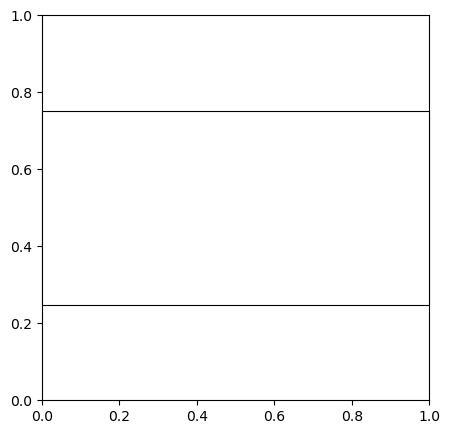

In [ ]:
proj = ccrs.PlateCarree()

fig, axes = plt.subplots(
    1, 1,
    figsize=(5, 5),
)
ax_rgb = fig.add_subplot(111, projection=proj)

ax_rgb.set_extent([-90, -80, 30, 40], crs=ccrs.PlateCarree())
rgb = np.dstack([landsat_data['red'], landsat_data['green'], landsat_data['blue']])
ax_rgb.pcolormesh(landsat_data_transformed['red'].x, landsat_data_transformed['red'].y,
    rgb,
    transform=proj,
)


In [ ]:
def normalize(band):
    """Linearly stretch a band to [0, 1]."""
    lo, hi = band.min(), band.max()
    return np.zeros_like(band) if hi == lo else (band - lo) / (hi - lo)

